In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
predictions = pd.read_csv('trained_models/2025-05-27-09/fold_1_EPInformer-PE-Activity-HiC.preTrainedConv.4base.64dim.3Trans.4head.' \
                          'TrueBN.TrueLN.TrueFeat.3extraFeat.60enh.K562.multi_predictions.csv')
predictions

,Unnamed: 0,PredExpr,ActualExpr,fold_idx
0,ENSG00000029363,1.578494,1.893984,1
1,ENSG00000113569,1.552984,1.852663,1
2,ENSG00000129158,1.491698,1.150449,1
3,ENSG00000170949,1.509784,1.232996,1
4,ENSG00000126653,1.537532,1.039810,1
...,...,...,...,...
713,ENSG00000178982,1.591693,2.521987,1
714,ENSG00000115524,1.516994,2.467549,1
715,ENSG00000115355,1.519096,1.726157,1
716,ENSG00000133943,1.506723,1.267875,1


In [3]:
def plot_predictions(predictions, cell_line, pred_col, actual_col):
    pearsonR, _ = stats.pearsonr(predictions[pred_col], predictions[actual_col])
    plt.figure(figsize=(6,6))
    ax = sns.jointplot(
        data=predictions,
        x=pred_col,
        y=actual_col,
        kind = 'scatter',
        joint_kws={'marker':'o', 's':10, 'alpha':0.5, 'linewidth':0},
        marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
    )
    prediction_task = 'PSI' if 'Psi' in pred_col else 'Expression'
    ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
    plt.title(f"{cell_line} {prediction_task} Prediction (Pearson R: {pearsonR:.2f})")
    plt.ylabel(f'{cell_line} {prediction_task} (actual)')
    plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
    if prediction_task == 'PSI':
        plt.xlim(-0.1, 1.1)
        plt.ylim(-0.1, 1.1)
    else:
        plt.xlim(-1, 5)
        plt.ylim(-1, 5)
    plt.tight_layout()
    

<Figure size 600x600 with 0 Axes>

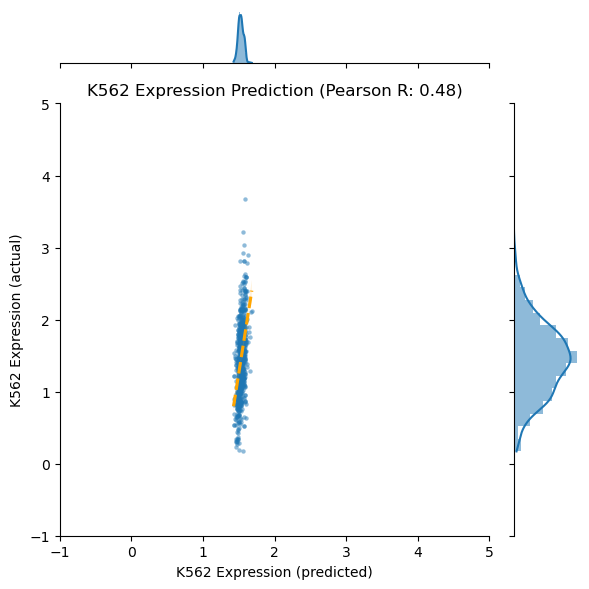

In [4]:
plot_predictions(predictions, cell_line='K562', pred_col='PredExpr', actual_col='ActualExpr')
plt.show()

<Figure size 600x600 with 0 Axes>

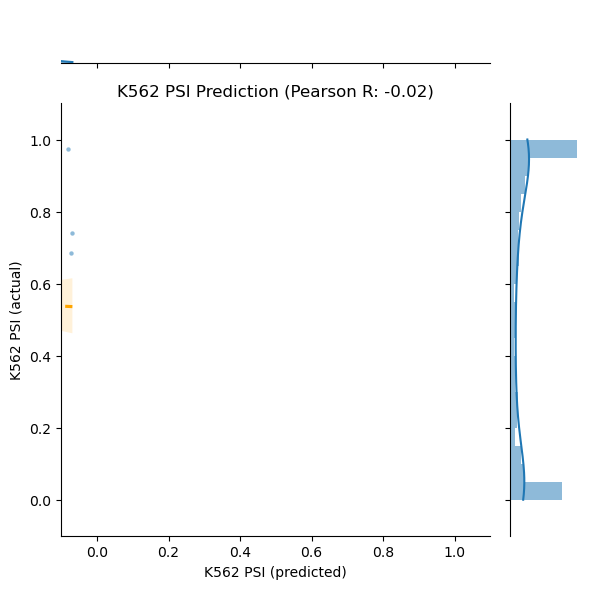

In [5]:
plot_predictions(predictions, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
plt.show()